# sEEG Multi-Class Deep Learning Analysis

This notebook implements a 4-class Deep Learning pipeline using a 1D CNN:
1. Load all trials from 4 class folders in `dataset/`
2. Detect bad channels and pad them with zeros
3. Apply notch + bandpass filtering and compute LMP
4. Build overlapping windows with class labels
5. Combine HFB + LMP windows into (n_windows, 552, 250) tensors
6. Train and evaluate an EEGNet-style 1D CNN model

## Step 0 - Imports and Function Definitions
Define all preprocessing and model functions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
from pathlib import Path


def detect_bad_channels_stat(data, standard_range=(-500, 500)):
    """Detect bad sEEG channels using statistical features.

    Args:
        data: Array with shape (n_channels, n_samples).
        standard_range: Acceptable amplitude range in microvolts.
    """
    bad_channels_indices = []

    constant_mask = np.all(np.isclose(data, data[:, [0]], atol=1e-5), axis=1)
    constant_channels = np.where(constant_mask)[0]
    bad_channels_indices.extend(constant_channels)

    means = np.mean(data, axis=1)
    offset_mask = np.abs(means) > 20
    offset_channels = np.where(offset_mask)[0]
    bad_channels_indices.extend(offset_channels)

    outside_mask = np.any(
        (data < standard_range[0]) | (data > standard_range[1]),
        axis=1,
    )
    outside_channels = np.where(outside_mask)[0]
    bad_channels_indices.extend(outside_channels)

    unique_bad_channels = sorted(set(bad_channels_indices))

    print(f"Constant channels: {constant_channels}")
    print(f"Offset channels: {offset_channels}")
    print(f"Outside standard range: {outside_channels}")

    return unique_bad_channels


def pad_bad_channels(data, bad_indices, n_channels=276):
    """Pad bad channels with zeros.
    
    Args:
        data: Array with shape (n_channels, n_samples)
        bad_indices: List/array of bad channel indices
        n_channels: Total number of channels (default 276)
    
    Returns:
        Data with bad channels replaced by zeros
    """
    padded_data = data.copy()
    for idx in bad_indices:
        padded_data[idx, :] = 0
    return padded_data


def bandpass_filter(data, low_freq, high_freq, fs=2000, order=4):
    """Apply a band-pass filter to extract a target frequency band.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        low_freq: Low cutoff frequency in Hz.
        high_freq: High cutoff frequency in Hz.
        fs: Sampling rate in Hz (default: 2000).
        order: Filter order (default: 4).

    Returns:
        Filtered data with the same shape as input.
    """
    nyquist = fs / 2
    low = low_freq / nyquist
    high = high_freq / nyquist

    b, a = butter(order, [low, high], btype="band")
    filtered_data = filtfilt(b, a, data, axis=1)

    return filtered_data


def apply_notch_filter(data, freq=50, fs=2000, q=30):
    """Apply a notch filter to remove power-line interference.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        freq: Frequency to remove in Hz (50 or 60 typically).
        fs: Sampling rate in Hz.
        q: Quality factor; higher values produce a narrower notch.

    Returns:
        Filtered data with the same shape as input.
    """
    nyquist = fs / 2
    w0 = freq / nyquist

    b, a = iirnotch(w0, q)
    filtered_data = filtfilt(b, a, data, axis=1)

    return filtered_data


def create_windows(data, window_size, stride):
    """Create overlapping windows from channel-by-time data.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        window_size: Window length in samples.
        stride: Step between consecutive windows in samples.

    Returns:
        3D array with shape (n_windows, n_channels, window_size).
    """
    _, n_samples = data.shape
    windows = []
    for i in range(0, n_samples - window_size + 1, stride):
        windows.append(data[:, i : i + window_size])
    return np.array(windows)


def calculate_lmp(data, window_ms=250, fs=2000):
    """Calculate Local Motor Potential (LMP) as a running average.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        window_ms: Window size for running average in milliseconds.
        fs: Sampling rate in Hz.

    Returns:
        LMP data with the same shape as input.
    """
    window_size = int(window_ms * fs / 1000)
    window = np.ones(window_size) / window_size
    lmp_data = np.apply_along_axis(
        lambda x: np.convolve(x, window, mode="same"),
        axis=1,
        arr=data,
    )
    return lmp_data


def filter_seeg_data(data, fs=2000):
    """Run the full sEEG filtering pipeline.

    Steps:
        1) Apply notch filtering to remove power-line noise.
        2) Apply band-pass filtering to obtain low/high frequency bands.
        3) Calculate Local Motor Potential (LMP) as running average.
    """
    data_no_notch = apply_notch_filter(data, freq=50, fs=fs)
    lfb_result = bandpass_filter(data_no_notch, 0.5, 30, fs)
    hfb_result = bandpass_filter(data_no_notch, 80, 200, fs)
    lmp_result = calculate_lmp(data_no_notch, window_ms=250, fs=fs)
    return lfb_result, hfb_result, lmp_result


np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (12, 4)

## Step 1 - Load All Class Data
Load `.npz` files from each class folder. Each file is one trial with shape `(channels, samples)`.

In [2]:
dataset_dir = Path('dataset')

class_configs = [
    ('class_1_关一下灯', '关一下灯'),
    ('class_2_我冷了', '我冷了'),
    ('class_3_我想出门走走', '我想出门走走'),
    ('class_4_现在几点了', '现在几点了'),
]

class_names = [cfg[1] for cfg in class_configs]
all_trials = []

for cls_idx, (folder_name, display_name) in enumerate(class_configs):
    folder = dataset_dir / folder_name
    npz_files = sorted(folder.glob('*.npz'))
    trials = []
    for f in npz_files:
        data = np.load(f)
        arr = data[data.files[0]]
        if arr.shape[0] > arr.shape[1]:
            arr = arr.T
        trials.append(arr)
    all_trials.append(trials)
    print(f'Class {cls_idx} ({display_name}): {len(trials)} trials, shape {trials[0].shape if trials else "N/A"}')

n_classes = len(all_trials)
n_channels = all_trials[0][0].shape[0]
print(f'\nTotal: {n_classes} classes, {n_channels} channels, {sum(len(t) for t in all_trials)} trials')

Class 0 (关一下灯): 20 trials, shape (276, 8480)
Class 1 (我冷了): 20 trials, shape (276, 8420)
Class 2 (我想出门走走): 20 trials, shape (276, 8400)
Class 3 (现在几点了): 20 trials, shape (276, 8400)

Total: 4 classes, 276 channels, 80 trials


## Step 2 - Detect and Pad Bad Channels
Concatenate all trials along the time axis to get a robust estimate of bad channels, then pad them with zeros in every trial instead of removing them, preserving the original channel count.

In [3]:
all_trials_flat = [trial for cls_trials in all_trials for trial in cls_trials]
concatenated = np.concatenate(all_trials_flat, axis=1)
print(f'Concatenated data shape: {concatenated.shape}')

bad_indices = detect_bad_channels_stat(concatenated)
print(f'\nBad channels ({len(bad_indices)} total): {bad_indices}')

# Pad bad channels with 0 instead of removing them
for cls_idx in range(n_classes):
    for trial_idx in range(len(all_trials[cls_idx])):
        all_trials[cls_idx][trial_idx] = pad_bad_channels(all_trials[cls_idx][trial_idx], bad_indices, n_channels)

n_channels_clean = all_trials[0][0].shape[0]
print(f'\nChannels after padding: {n_channels_clean} (expected: same as original)')

Concatenated data shape: (276, 674560)


c:\Users\hilin\miniconda3\envs\data_env\lib\site-packages\numpy\_core\_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Constant channels: [272 273 274 275]
Offset channels: [256 257 258 259 260 261 262 263 264 265 266 267 272 273 274]
Outside standard range: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  24
  25  26  27  30  31  35  39  40  41  42  43  44  45  46  47  49  50  51
  52  53  54  55  56  57  58  59  60  61  62  63  64  65  73  74  75  77
  78  79  80  81  82  85  94  95  96  97  98  99 100 101 102 103 104 105
 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123
 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141
 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159
 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195
 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213
 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231
 232 233 234 235 236 237 238 239 240 241 242 243 244 245 

## Step 3 - Filter All Trials
Apply the full preprocessing pipeline (notch -> HFB/LFB -> LMP) to every trial.

In [4]:
fs = 2000

all_hfb_trials = []
all_lmp_trials = []

for cls_idx in range(n_classes):
    cls_hfb = []
    cls_lmp = []
    for trial in all_trials[cls_idx]:
        _, hfb, lmp = filter_seeg_data(trial, fs=fs)
        cls_hfb.append(hfb)
        cls_lmp.append(lmp)
    all_hfb_trials.append(cls_hfb)
    all_lmp_trials.append(cls_lmp)

print(f'HFB trial shapes: {[t.shape for t in all_hfb_trials[0][:3]]}...')
print(f'LMP trial shapes: {[t.shape for t in all_lmp_trials[0][:3]]}...')

HFB trial shapes: [(276, 8480), (276, 8400), (276, 8400)]...
LMP trial shapes: [(276, 8480), (276, 8400), (276, 8400)]...


## Step 4 - Create Overlapping Windows with Labels
Cut each trial into overlapping windows and assign the trial's class label to all its windows.

In [5]:
window_size = 250
stride = 225

hfb_windows_list = []
lmp_windows_list = []
labels_list = []

for cls_idx in range(n_classes):
    for trial_hfb, trial_lmp in zip(all_hfb_trials[cls_idx], all_lmp_trials[cls_idx]):
        hfb_w = create_windows(trial_hfb, window_size=window_size, stride=stride)
        lmp_w = create_windows(trial_lmp, window_size=window_size, stride=stride)
        n_w = len(hfb_w)
        hfb_windows_list.append(hfb_w)
        lmp_windows_list.append(lmp_w)
        labels_list.append(np.full(n_w, cls_idx, dtype=int))

hfb_windows = np.concatenate(hfb_windows_list, axis=0)
lmp_windows = np.concatenate(lmp_windows_list, axis=0)
labels = np.concatenate(labels_list, axis=0)

print(f'Total windows: {len(labels)}')
print(f'HFB windows shape: {hfb_windows.shape}')
print(f'LMP windows shape: {lmp_windows.shape}')
print(f'\nWindows per class:')
for cls_idx, name in enumerate(class_names):
    count = np.sum(labels == cls_idx)
    print(f'  Class {cls_idx} ({name}): {count} windows')

Total windows: 2960
HFB windows shape: (2960, 276, 250)
LMP windows shape: (2960, 276, 250)

Windows per class:
  Class 0 (关一下灯): 740 windows
  Class 1 (我冷了): 740 windows
  Class 2 (我想出门走走): 740 windows
  Class 3 (现在几点了): 740 windows


## Step 5 - Prepare PyTorch Dataset
Combine HFB and LMP into a 552-channel input, then normalize using training set statistics and create PyTorch dataloaders.

In [6]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit

# 1) Combine HFB and LMP into 552 channels: (N, 2*C, T)
X_combined = np.concatenate([hfb_windows, lmp_windows], axis=1)
print(f"Combined tensor shape: {X_combined.shape}")

# 2) Train/Test Split (80/20, stratified by class)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X_combined, labels))

X_train, X_test = X_combined[train_idx], X_combined[test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

# 3) Normalize tracking over channels and time dimensions using training set stats
mean = X_train.mean(axis=(0, 2), keepdims=True)
std = X_train.std(axis=(0, 2), keepdims=True)

X_train_norm = (X_train - mean) / (std + 1e-8)
X_test_norm = (X_test - mean) / (std + 1e-8)

# 4) Create DataLoaders
train_dataset = TensorDataset(torch.tensor(X_train_norm, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test_norm, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Combined tensor shape: (2960, 552, 250)
Train size: 2368  |  Test size: 592


## Step 6 - Define the EEGNet-style 1D CNN Model
A 3-block 1D CNN to quickly process the 552 channels to classify the sequences.

In [8]:
import torch.nn as nn

class EEGNet1D(nn.Module):
    def __init__(self, in_channels=552, n_classes=4, dropout_rate=0.5):
        super(EEGNet1D, self).__init__()
        
        # Block 1: Channel compression (kernel_size=1)
        self.block1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=1, padding='same'),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout_rate)
        )
        
        # Block 2: Temporal feature extraction (kernel_size=3)
        self.block2 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout_rate)
        )
        
        # Block 3: Temporal feature extraction (kernel_size=5)
        self.block3 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=5, padding='same'),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout_rate)
        )
        
        # Block 4: Classification
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, n_classes),
            nn.LogSoftmax(dim=1)
        )
    
    def forward(self, x):
        # x shape: (batch, 552, 250)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")
model = EEGNet1D().to(device)
print(model)

Using device cpu
EEGNet1D(
  (block1): Sequential(
    (0): Conv1d(552, 64, kernel_size=(1,), stride=(1,), padding=same)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.5, inplace=False)
  )
  (block2): Sequential(
    (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.5, inplace=False)
  )
  (block3): Sequential(
    (0): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=same)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=4, bias=True)
    (3): LogSoftmax(dim=

## Step 7 - Training
Train the CNN using early stopping based on the test set accuracy (used as validation for tuning).

In [9]:
def train_model(model, train_loader, val_loader, device, epochs=50, patience=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    best_val_acc = 0.0
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
        
        train_acc = train_correct / train_total
        
        # Validation phase
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)
                
                outputs = model(batch_x)
                _, predicted = torch.max(outputs, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()
        
        val_acc = val_correct / val_total
        
        print(f"Epoch {epoch+1:02d}/{epochs} - Train Loss: {train_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    return model

model = train_model(model, train_loader, test_loader, device, epochs=50, patience=5)
model.load_state_dict(torch.load('best_model.pth'))

Epoch 01/50 - Train Loss: 1.1994, Train Acc: 0.4485, Val Acc: 0.5895
Epoch 02/50 - Train Loss: 0.8983, Train Acc: 0.6225, Val Acc: 0.6706
Epoch 03/50 - Train Loss: 0.7410, Train Acc: 0.7090, Val Acc: 0.7128
Epoch 04/50 - Train Loss: 0.6395, Train Acc: 0.7437, Val Acc: 0.7872
Epoch 05/50 - Train Loss: 0.5755, Train Acc: 0.7715, Val Acc: 0.7838
Epoch 06/50 - Train Loss: 0.4667, Train Acc: 0.8252, Val Acc: 0.8598
Epoch 07/50 - Train Loss: 0.4444, Train Acc: 0.8361, Val Acc: 0.8564
Epoch 08/50 - Train Loss: 0.3810, Train Acc: 0.8501, Val Acc: 0.8868
Epoch 09/50 - Train Loss: 0.3431, Train Acc: 0.8712, Val Acc: 0.8885
Epoch 10/50 - Train Loss: 0.3192, Train Acc: 0.8809, Val Acc: 0.8919
Epoch 11/50 - Train Loss: 0.2966, Train Acc: 0.8898, Val Acc: 0.9020
Epoch 12/50 - Train Loss: 0.2503, Train Acc: 0.9130, Val Acc: 0.9257
Epoch 13/50 - Train Loss: 0.2446, Train Acc: 0.9088, Val Acc: 0.9426
Epoch 14/50 - Train Loss: 0.2205, Train Acc: 0.9210, Val Acc: 0.9341
Epoch 15/50 - Train Loss: 0.1937, 

<All keys matched successfully>

## Step 8 - Evaluate Model
Visualize the model predictions against the true labels from the test dataset.


Test Accuracy: 0.9713

Classification Report:
              precision    recall  f1-score   support

        关一下灯       0.99      0.97      0.98       148
         我冷了       0.96      0.97      0.97       148
      我想出门走走       0.99      0.96      0.98       148
       现在几点了       0.94      0.98      0.96       148

    accuracy                           0.97       592
   macro avg       0.97      0.97      0.97       592
weighted avg       0.97      0.97      0.97       592



C:\Users\hilin\AppData\Local\Temp\ipykernel_14924\2845604577.py:32: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_14924\2845604577.py:32: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_14924\2845604577.py:32: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_14924\2845604577.py:32: UserWarning: Glyph 28783 (\N{CJK UNIFIED IDEOGRAPH-706F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_14924\2845604577.py:32: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_14924\2845604577.py:32: UserWarning: Glyph 20919 (\

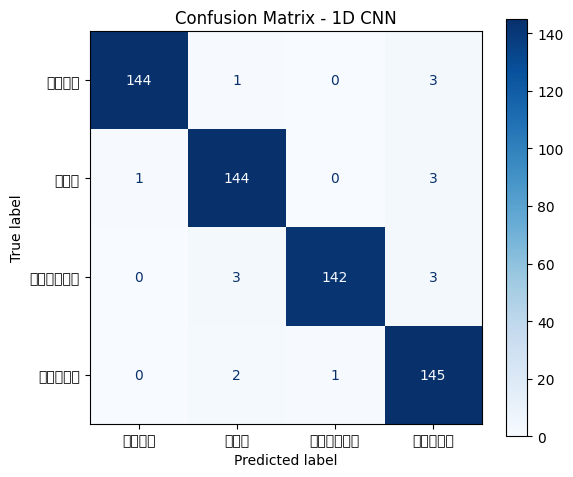

In [10]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_model(model, test_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.numpy())
    
    # Overall accuracy
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"\nTest Accuracy: {accuracy:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Confusion Matrix - 1D CNN")
    plt.tight_layout()
    plt.show()
    
    return accuracy, cm

_, _ = evaluate_model(model, test_loader, device, class_names)

## Step 9 - Inference Time Profiling
Measure the average time it takes for the CNN model to process a single window (batch size = 1) useful for real-time BCI scenarios.

In [ ]:
import time

def measure_inference_time(model, device, in_channels=552, seq_length=250, n_iterations=1000):
    model.eval()
    
    # Create a dummy tensor representing a single window
    dummy_input = torch.randn(1, in_channels, seq_length).to(device)
    
    # Warm-up phase (prevent initialization overhead from affecting results)
    with torch.no_grad():
        for _ in range(50):
            _ = model(dummy_input)
            
    # Measure time
    if device.type == "cuda":
        torch.cuda.synchronize()
        
    start_time = time.perf_counter()
    
    with torch.no_grad():
        for _ in range(n_iterations):
            _ = model(dummy_input)
            
    if device.type == "cuda":
        torch.cuda.synchronize()
        
    end_time = time.perf_counter()
    
    total_time = end_time - start_time
    avg_time_ms = (total_time / n_iterations) * 1000
    throughput = 1000 / avg_time_ms if avg_time_ms > 0 else float('inf')
    
    print("-" * 50)
    print(f"Inference Time Profiling (Device: {device})")
    print(f"Batch Size       : 1")
    print(f"Input Shape      : (1, {in_channels}, {seq_length})")
    print(f"Iterations       : {n_iterations}")
    print(f"Average Time/Win : {avg_time_ms:.4f} ms")
    print(f"Max Throughput   : {throughput:.2f} windows/second")
    print("-" * 50)

# Run the inference time benchmark
measure_inference_time(model, device)